# Adversarial Robustness with Certified Defenses

The Problem: Deep learning models have been shown to be vulnerable to “adversarial attacks”-that is, tiny, often imperceptible modifications to the inputs, which can cause the model to output erroneous results. Common defenses simply rely on memorizing specific attacks, and are thus vulnerable to new attacks developed mathematically.
The Approach: This notebook demonstrates a Certified Defense using the randomized smoothing defense mechanism. Instead of a hoped-for robustness, this method provides a rigorous mathematical guarantee of a model's security properties.
The Guarantee: By injecting random noise into training data, then averaging hundreds of samples at inference time, our defense produces a “Certified Radius,” which guarantees against all attacks of a certain magnitude (a size measured in the Euclidean norm). It is thus protected even against adversarial attacks that have not yet been conceived by an adversary.
Evaluation: Below, we evaluate the resulting certified accuracy on data that you provide, along with plots for understanding how certified accuracy relates to the standard accuracy. This allows for engineering a system that is robust against adversarially modified input data.

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.69MB/s]


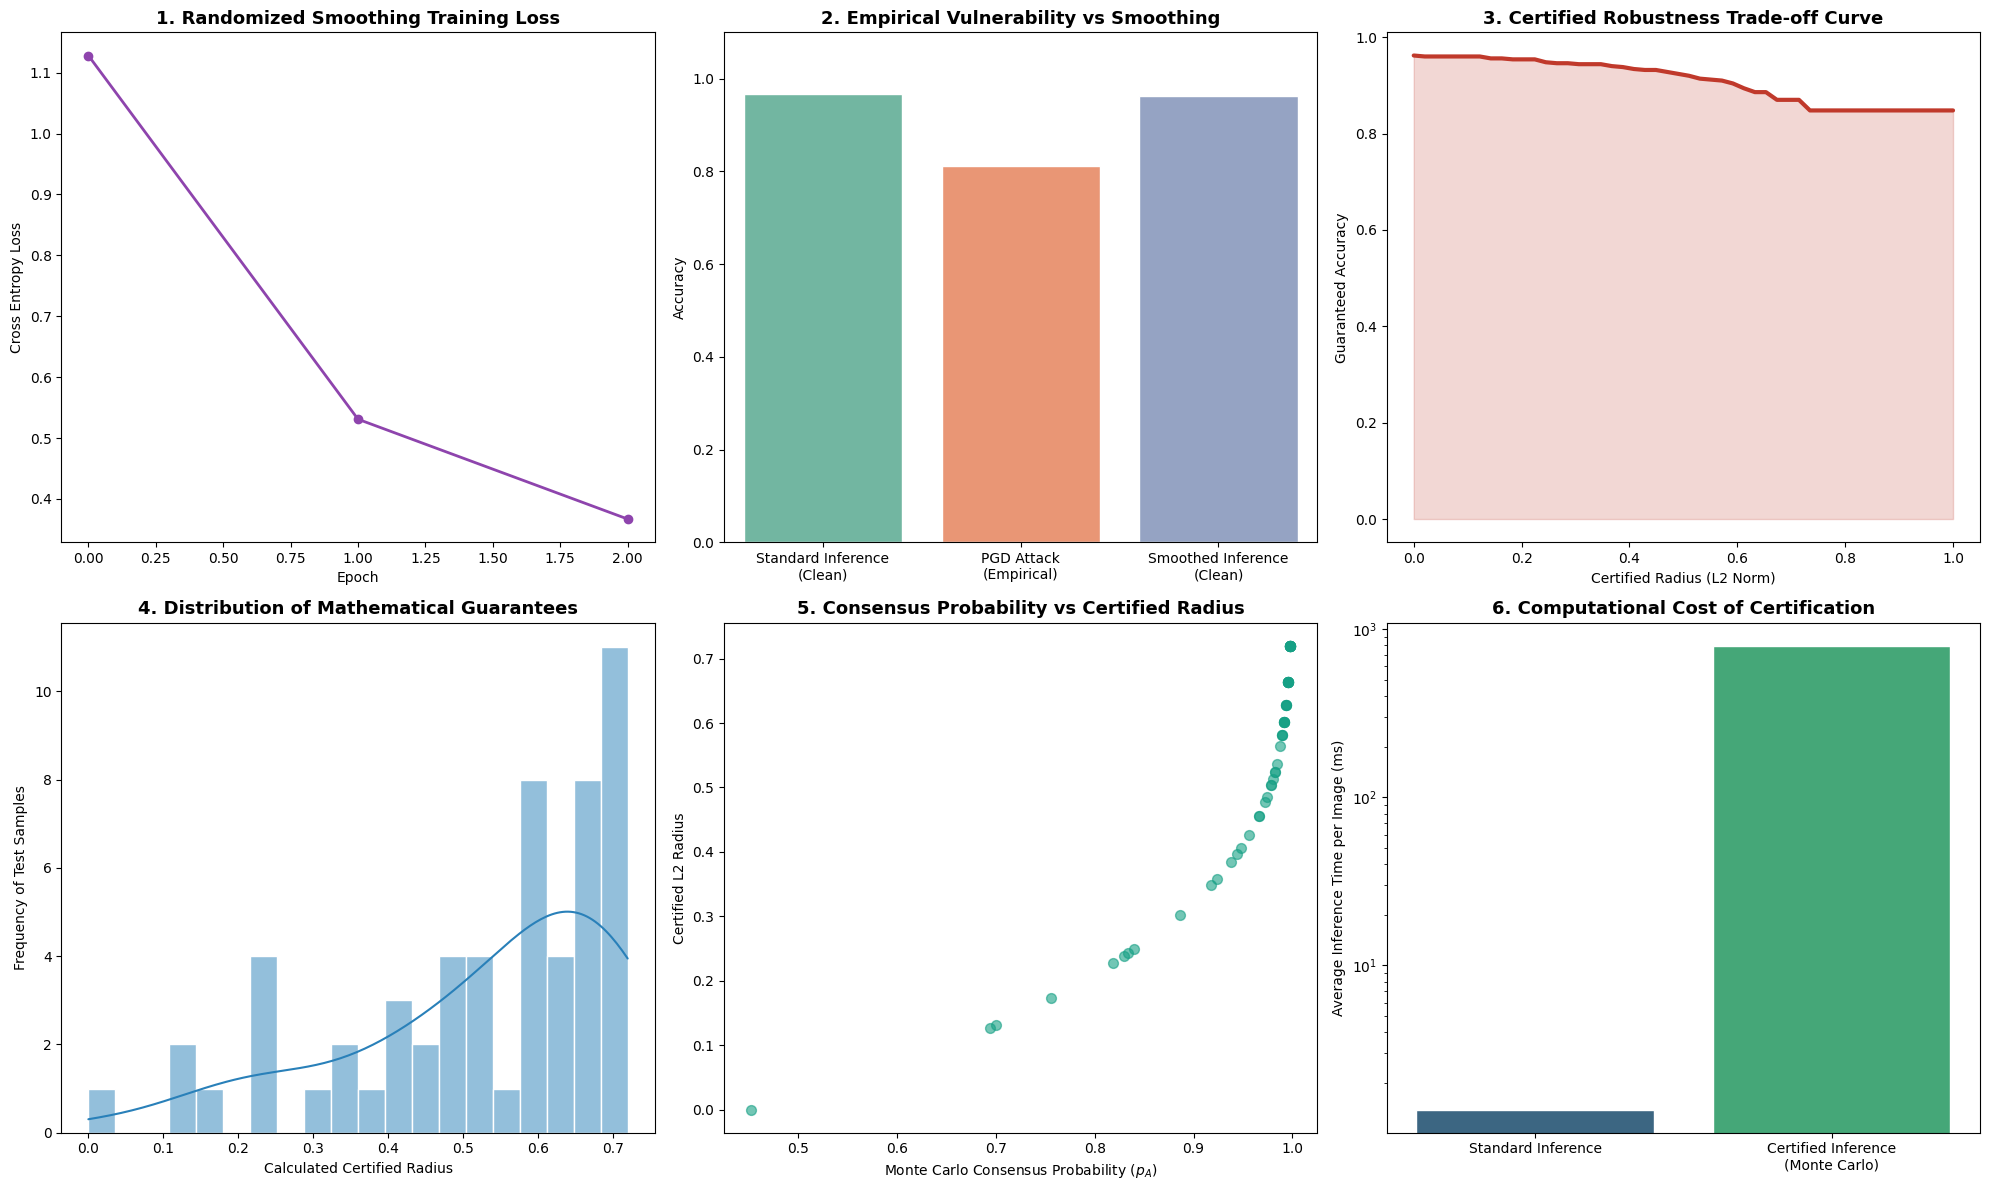

In [ ]:

import os
import warnings
import logging

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
logging.getLogger().setLevel(logging.ERROR)

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
import time

class RobustCNN(nn.Module):
    def __init__(self):
        super(RobustCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

def pgd_attack(model, images, labels, eps, alpha, steps):
    images = images.clone().detach().to(images.device)
    labels = labels.to(images.device)
    original_images = images.clone().detach()

    images.requires_grad = True

    for _ in range(steps):
        images.requires_grad = True
        outputs = model(images)
        model.zero_grad()
        loss = F.cross_entropy(outputs, labels)
        loss.backward()

        adv_images = images + alpha * images.grad.sign()
        eta = torch.clamp(adv_images - original_images, min=-eps, max=eps)
        images = torch.clamp(original_images + eta, min=0, max=1).detach()

    return images

def run_certified_defense():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    transform = transforms.Compose([transforms.ToTensor()])
    full_train_dataset = datasets.MNIST('../data', train=True, download=True, transform=transform)
    full_test_dataset = datasets.MNIST('../data', train=False, transform=transform)

    train_indices = np.random.choice(len(full_train_dataset), 5000, replace=False)
    test_indices = np.random.choice(len(full_test_dataset), 500, replace=False)

    train_loader = DataLoader(Subset(full_train_dataset, train_indices), batch_size=64, shuffle=True)
    test_loader = DataLoader(Subset(full_test_dataset, test_indices), batch_size=1, shuffle=False)

    model = RobustCNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    sigma = 0.25
    epochs = 3

    train_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            noise = torch.randn_like(data) * sigma
            noisy_data = torch.clamp(data + noise, 0, 1)

            optimizer.zero_grad()
            output = model(noisy_data)
            loss = F.cross_entropy(output, target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))

    model.eval()

    clean_correct = 0
    pgd_correct = 0
    total = 0

    eps = 0.1
    alpha = 0.02
    steps = 10

    certified_radii = []
    smoothed_correct = 0
    confidences = []

    cert_times = []
    std_times = []

    N0 = 100
    N = 500

    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        total += 1

        start_std = time.time()
        with torch.no_grad():
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            if pred.item() == target.item():
                clean_correct += 1
        std_times.append(time.time() - start_std)

        adv_data = pgd_attack(model, data, target, eps, alpha, steps)
        with torch.no_grad():
            adv_output = model(adv_data)
            adv_pred = adv_output.argmax(dim=1, keepdim=True)
            if adv_pred.item() == target.item():
                pgd_correct += 1

        start_cert = time.time()
        with torch.no_grad():
            counts0 = torch.zeros(10).to(device)
            for _ in range(N0):
                noise = torch.randn_like(data) * sigma
                noisy_data = torch.clamp(data + noise, 0, 1)
                out = model(noisy_data)
                counts0 += F.one_hot(out.argmax(dim=1), num_classes=10).sum(dim=0)

            c_hat = counts0.argmax().item()

            counts = 0
            for _ in range(N):
                noise = torch.randn_like(data) * sigma
                noisy_data = torch.clamp(data + noise, 0, 1)
                out = model(noisy_data)
                if out.argmax(dim=1).item() == c_hat:
                    counts += 1

        cert_times.append(time.time() - start_cert)

        pA = counts / N
        confidences.append(pA)

        if c_hat == target.item():
            smoothed_correct += 1
            if pA > 0.5:
                radius = sigma * norm.ppf(pA)
                certified_radii.append(radius)
            else:
                certified_radii.append(0.0)
        else:
            certified_radii.append(-1.0)

    certified_radii = np.array(certified_radii)

    radii_thresholds = np.linspace(0, 1.0, 50)
    certified_acc = []
    for r in radii_thresholds:
        acc = np.sum(certified_radii >= r) / total
        certified_acc.append(acc)

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    sns.set_style("whitegrid")

    axes[0, 0].plot(train_losses, marker='o', color='#8e44ad', linewidth=2)
    axes[0, 0].set_title('1. Randomized Smoothing Training Loss', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Cross Entropy Loss')

    acc_labels = ['Standard Inference\n(Clean)', 'PGD Attack\n(Empirical)', 'Smoothed Inference\n(Clean)']
    acc_values = [clean_correct/total, pgd_correct/total, smoothed_correct/total]
    sns.barplot(x=acc_labels, y=acc_values, ax=axes[0, 1], palette='Set2')
    axes[0, 1].set_title('2. Empirical Vulnerability vs Smoothing', fontsize=13, fontweight='bold')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_ylim(0, 1.1)

    axes[0, 2].plot(radii_thresholds, certified_acc, color='#c0392b', linewidth=3)
    axes[0, 2].fill_between(radii_thresholds, certified_acc, color='#c0392b', alpha=0.2)
    axes[0, 2].set_title('3. Certified Robustness Trade-off Curve', fontsize=13, fontweight='bold')
    axes[0, 2].set_xlabel('Certified Radius (L2 Norm)')
    axes[0, 2].set_ylabel('Guaranteed Accuracy')

    valid_radii = certified_radii[certified_radii >= 0]
    sns.histplot(valid_radii, bins=20, kde=True, color='#2980b9', ax=axes[1, 0])
    axes[1, 0].set_title('4. Distribution of Mathematical Guarantees', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel('Calculated Certified Radius')
    axes[1, 0].set_ylabel('Frequency of Test Samples')

    valid_conf = np.array(confidences)[certified_radii >= 0]
    axes[1, 1].scatter(valid_conf, valid_radii, color='#16a085', alpha=0.6, s=50)
    axes[1, 1].set_title('5. Consensus Probability vs Certified Radius', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel('Monte Carlo Consensus Probability ($p_A$)')
    axes[1, 1].set_ylabel('Certified L2 Radius')

    time_labels = ['Standard Inference', 'Certified Inference\n(Monte Carlo)']
    time_values = [np.mean(std_times) * 1000, np.mean(cert_times) * 1000]
    sns.barplot(x=time_labels, y=time_values, ax=axes[1, 2], palette='viridis')
    axes[1, 2].set_title('6. Computational Cost of Certification', fontsize=13, fontweight='bold')
    axes[1, 2].set_ylabel('Average Inference Time per Image (ms)')
    axes[1, 2].set_yscale('log')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_certified_defense()